# Hyperparameter Tuning: Loop Closure Weight — Latent JacobianODE (Lorenz Full Obs)

This notebook performs a **Hydra grid sweep** over `loop_closure_weight` values for the
**Latent JacobianODE** model in the fully-observed 3D Lorenz setting (the same setup as
`Latent JacobianODE (Lorenz - full obs, identity test).ipynb`).

**Setting:**
- Input: Fully observed 3D Lorenz (all 3 coords, no noise)
- Encoder: LRU (SSM) without positional encoding — `(B, T, 3)` → `(B, T, 3)`
- Latent space: 3D (same dimension as the true system)
- Decoder: Pointwise MLP — `(B, T, 3)` → `(B, T, 3)`

**Workflow:**
1. Set hyperparameters matching the identity-test notebook
2. Build the base config and generate data
3. Launch a Hydra `--multirun` sweep over `loop_closure_weight` values via SLURM
4. After training, query W&B to collect run IDs
5. Apply the physics-informed model selection criteria (C1/C2/C3) to pick the best λ
6. Load and inspect the selected model

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from omegaconf import OmegaConf
import os
import torch
from torch.autograd.functional import jacobian as autograd_jacobian
from tqdm.auto import tqdm
import wandb


In [3]:
from JacobianODE.jacobians import (
    load_config,
    initialize_config,
    seed_everything,
    make_trajectories,
    postprocess_data,
    create_dataloaders,
    make_model,
    load_run,
    load_checkpoint,
)
from JacobianODE.jacobians.metrics import r2_score
from JacobianODE.jacobians.data.processing import normalize_data
from JacobianODE.jacobians.tuning import DEFAULT_LAMBDA_LOOP_VALUES
from JacobianODE.jacobians.tuning.criteria import (
    compute_all_diagnostics,
    DiagnosticMetrics,
)
from JacobianODE.jacobians.tuning.selection import select_best_model

In [4]:
seed_everything(42)

42

## 1. Hyperparameters

All hyperparameters match the `Latent JacobianODE (Lorenz - full obs, identity test)` notebook
exactly. Only `loop_closure_weight` is swept — all other settings are held fixed.

In [21]:
# ----------------------------------------------------------------
# Paths and W&B settings
# ----------------------------------------------------------------
SAVE_DIR     = "/orcd/data/ekmiller/001/eisenaj/JacobianODE/lightning/latent_jac_runs"
WANDB_ENTITY = "JacobianODE"

# W&B project — run_jacobians.py derives this automatically from the data type:
#   data_type=dysts + flow=Lorenz  →  'Lorenz__JacobianODE'
# The post-hoc evaluation queries this project to find the sweep runs.
WANDB_PROJECT   = "LorenzLatent_FS_LPL_BIG_JacobianODE"
WANDB_PROJECT_PATH = f"{WANDB_ENTITY}/{WANDB_PROJECT}"

In [22]:
# ----------------------------------------------------------------
# Data hyperparameters
# ----------------------------------------------------------------
OBS_NOISE        = 0.05          # No noise: cleanest identity test
OBSERVED_INDICES = [0, 1, 2]     # Observe ALL three Lorenz dimensions
N_PERIODS        = 15            # Lorenz periods to simulate
PTS_PER_PERIOD   = 100           # Temporal resolution (dt ≈ 0.015)
NUM_ICS          = 32            # Independent initial conditions

# Known Lorenz Lyapunov exponents (σ=10, ρ=28, β=8/3)
TRUE_LYAPUNOV = [0.91, 0.0, -14.57]

In [23]:
# ----------------------------------------------------------------
# Encoder / Latent space hyperparameters
# ----------------------------------------------------------------
N_LATENT = 3      # Must equal the true system dimension

# LRU encoder (no positional encoding)
# SSM_D_MODEL    = 64
# SSM_D_STATE    = 32
SSM_D_MODEL    = 128
SSM_D_STATE    = 64
SSM_N_LAYERS   = 3
SSM_R_MIN      = 0.9
SSM_R_MAX      = 0.999
SSM_FFN_EXPAND = 4
SSM_DROPOUT    = 0.1

# Decoder MLP (pointwise: z_t → x̂_t)
# DECODER_HIDDEN = 128
# DECODER_LAYERS = 2
# DECODER_LAYERS = 0
DECODER_HIDDEN = 512
DECODER_LAYERS = 3

In [24]:
# ----------------------------------------------------------------
# Jacobian MLP hyperparameters
# ----------------------------------------------------------------
# JAC_HIDDEN_DIM = [512, 512, 512]
# JAC_NUM_LAYERS = 3
JAC_HIDDEN_DIM = [256, 1024, 2048, 2048]
JAC_NUM_LAYERS = 4
JAC_ACTIVATION = 'silu'

In [25]:
# ----------------------------------------------------------------
# Training hyperparameters
# ----------------------------------------------------------------
BATCH_SIZE               = 32
MAX_EPOCHS               = 150
LIMIT_TRAIN_BATCHES      = 200
LIMIT_VAL_BATCHES        = 50
ACCUMULATE_GRAD_BATCHES  = 1
LEARNING_RATE            = 1e-4
WEIGHT_DECAY             = 1e-4

ENCODER_WARMUP_EPOCHS    = 0
TRAJ_INIT_STEPS          = 15
PREDICTION_STEPS         = 10
RECONSTRUCTION_LOSS_WEIGHT = 1.0
LATENT_PREDICTION_LOSS_WEIGHT = 1.0
INTERP_PTS               = 4
INNER_N                  = 20
JAC_WINDOW_STRIDE        = 5
EARLY_STOPPING_PATIENCE  = 2

# ----------------------------------------------------------------
# Loop closure weight sweep values
# ----------------------------------------------------------------
LAMBDA_LOOP_VALUES = DEFAULT_LAMBDA_LOOP_VALUES   # [0, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 10]
print(f"Sweep values: {LAMBDA_LOOP_VALUES}")

Sweep values: [0, 1e-06, 1e-05, 0.0001, 0.001, 0.01, 0.1, 1, 10]


In [26]:
# ----------------------------------------------------------------
# Sequence length calculation
# ----------------------------------------------------------------
JAC_WINDOW = TRAJ_INIT_STEPS + PREDICTION_STEPS          # = 25
SEQ_LENGTH = JAC_WINDOW + JAC_WINDOW_STRIDE * 5          # = 50  (6 sub-windows)

n_sub_windows = (SEQ_LENGTH - JAC_WINDOW) // JAC_WINDOW_STRIDE + 1
print(f"JacobianODE window:      {JAC_WINDOW} = {TRAJ_INIT_STEPS} init + {PREDICTION_STEPS} pred")
print(f"Dataset sequence length: {SEQ_LENGTH}")
print(f"Sub-windows per batch:   {n_sub_windows}")
print(f"Effective samples/step:  {BATCH_SIZE * n_sub_windows}")

JacobianODE window:      25 = 15 init + 10 pred
Dataset sequence length: 50
Sub-windows per batch:   6
Effective samples/step:  192


## 2. Config Setup

Build the base config using the same overrides as the identity-test notebook.
This config is used both for local data generation (to compute the persistence baseline)
and as the template for the sweep command.

In [ ]:
# Format list-valued overrides without spaces so they double as valid Hydra CLI args
_hidden_dim_str = str(JAC_HIDDEN_DIM).replace(' ', '')
_obs_idx_str    = str(list(OBSERVED_INDICES)).replace(' ', '')

overrides = [
    # --- Model: LRU encoder without positional encoding ---
    "model=latent_ssm",
    f"model.encoder.n_input={len(OBSERVED_INDICES)}",
    f"model.encoder.n_latent={N_LATENT}",
    f"model.encoder.d_model={SSM_D_MODEL}",
    f"model.encoder.d_state={SSM_D_STATE}",
    f"model.encoder.n_layers={SSM_N_LAYERS}",
    f"model.encoder.r_min={SSM_R_MIN}",
    f"model.encoder.r_max={SSM_R_MAX}",
    f"model.encoder.ffn_expand={SSM_FFN_EXPAND}",
    f"model.encoder.dropout={SSM_DROPOUT}",
    "model.encoder.use_positional_encoding=False",
    f"model.encoder.decoder_hidden={DECODER_HIDDEN}",
    f"model.encoder.decoder_layers={DECODER_LAYERS}",
    "model.encoder.context_margin=0",

    # --- Jacobian MLP ---
    f"model.params.hidden_dim={_hidden_dim_str}",
    f"model.params.num_layers={JAC_NUM_LAYERS}",
    f"model.params.activation={JAC_ACTIVATION}",

    # --- Prediction steps & stride ---
    f"model.prediction_steps={PREDICTION_STEPS}",
    f"model.jac_window_stride={JAC_WINDOW_STRIDE}",
    f"model.encoder_warmup_epochs={ENCODER_WARMUP_EPOCHS}",

    # --- Data: fully observed Lorenz ---
    "data=dysts",
    "data.flow._target_=JacobianODE.dysts_sim.flows.Lorenz",
    f"data.trajectory_params.n_periods={N_PERIODS}",
    f"data.trajectory_params.pts_per_period={PTS_PER_PERIOD}",
    f"data.trajectory_params.num_ics={NUM_ICS}",
    f"data.postprocessing.obs_noise={OBS_NOISE}",
    "data.postprocessing.normalize=True",
    f"data.train_test_params.delay_embedding_params.observed_indices={_obs_idx_str}",
    "data.train_test_params.delay_embedding_params.n_delays=1",
    f"data.train_test_params.seq_length={SEQ_LENGTH}",

    # --- Save directory ---
    f"training.logger.save_dir={SAVE_DIR}",
    f"training.logger_save_dirs={SAVE_DIR}",

    # --- Training hyperparameters ---
    f"training.batch_size={BATCH_SIZE}",
    f"training.lightning.optimizer_kwargs.lr={LEARNING_RATE}",
    f"training.lightning.optimizer_kwargs.weight_decay={WEIGHT_DECAY}",
    "training.lightning.loop_closure_training=True",
    "training.lightning.trajectory_training=True",
    f"training.lightning.reconstruction_loss_weight={RECONSTRUCTION_LOSS_WEIGHT}",

    # --- Teacher forcing ---
    "training.lightning.alpha_teacher_forcing=1",
    "training.lightning.teacher_forcing_annealing=True",
    "training.lightning.gamma_teacher_forcing=0.999",

    # --- JacobianODEint ---
    f"training.lightning.jacobianODEint_kwargs.traj_init_steps={TRAJ_INIT_STEPS}",
    f"training.lightning.jacobianODEint_kwargs.interp_pts={INTERP_PTS}",
    f"training.lightning.jacobianODEint_kwargs.inner_N={INNER_N}",
    "training.lightning.jacobianODEint_kwargs.inner_path=line",

    # --- Trainer ---
    f"training.trainer_params.max_epochs={MAX_EPOCHS}",
    f"training.trainer_params.limit_train_batches={LIMIT_TRAIN_BATCHES}",
    f"training.trainer_params.limit_val_batches={LIMIT_VAL_BATCHES}",
    f"training.trainer_params.accumulate_grad_batches={ACCUMULATE_GRAD_BATCHES}",

    # --- Early stopping ---
    f"training.early_stopping.early_stopping_patience={EARLY_STOPPING_PATIENCE}",
]

cfg = load_config(overrides=overrides)
cfg = initialize_config(cfg)

print("Lightning target:", cfg.training.lightning._target_)
print(f"Encoder: n_input={cfg.model.encoder.n_input}, n_latent={cfg.model.encoder.n_latent}")
print(f"         use_positional_encoding={cfg.model.encoder.use_positional_encoding}")
print(f"         r_min={cfg.model.encoder.r_min}, r_max={cfg.model.encoder.r_max}")
print(f"Jacobian MLP: input_dim={cfg.model.params.input_dim}, output_dim={cfg.model.params.output_dim}")
print(f"Normalization: {cfg.data.postprocessing.normalize}")

## 3. Generate Data

Generate trajectories. We also z-score normalize (matching training-time normalization) and build
dataloaders so we have a consistent evaluation set for post-hoc diagnostics.

In [28]:
eq, sol, dt = make_trajectories(cfg, verbose=True)
print(f"\nFull trajectory shape: {sol['values'].shape}")
print(f"Time step dt = {dt:.4f}")


Full trajectory shape: (32, 1500, 3)
Time step dt = 0.0150


In [29]:
# Postprocess then z-score normalize (matches run_jacobians.py when
# data.postprocessing.normalize=True)
values_raw = postprocess_data(cfg, sol["values"])
values, mu, sigma = normalize_data(values_raw)
print(f"Postprocessed shape: {values.shape}")
print(f"Normalization: mu={mu:.4f}, sigma={sigma:.4f}")

Postprocessed shape: (32, 1500, 3)
Normalization: mu=8.4429, sigma=14.2548


In [30]:
train_dl, val_dl, test_dl, trajs = create_dataloaders(cfg, values, verbose=True)

n_dims          = values.shape[-1]

print(f"\nData dimensionality:  {n_dims}")
print(f"sqrt(n_dims) = {np.sqrt(n_dims):.4f}  (C2 loop-closure threshold)")

Sequence Indices:   0%|          | 0/1450 [00:00<?, ?it/s]

Train dataset shape: torch.Size([31900, 50, 3])
Validation dataset shape: torch.Size([10150, 50, 3])
Test dataset shape: torch.Size([4350, 50, 3])
Train trajectories dataset shape: torch.Size([22, 1500, 3])
Validation trajectories dataset shape: torch.Size([7, 1500, 3])
Test trajectories dataset shape: torch.Size([3, 1500, 3])

Data dimensionality:  3
sqrt(n_dims) = 1.7321  (C2 loop-closure threshold)


## 4. Launch Hydra Grid Sweep over `loop_closure_weight`

We use Hydra's `--multirun` mode with the SLURM launcher to submit one job per
`loop_closure_weight` value.  Each job trains the full Latent JacobianODE and logs
to W&B under the project **`Lorenz__JacobianODE`** (the name is derived automatically
from `data_type=dysts` + `flow=Lorenz`).

> **Wait for all SLURM jobs to finish** before proceeding to Section 5.

In [31]:
# ----------------------------------------------------------------
# Check which lambda values already have completed runs on W&B
# ----------------------------------------------------------------
api = wandb.Api()
try:
    existing_runs = api.runs(WANDB_PROJECT_PATH)
    print(f"Found {len(existing_runs)} total runs in {WANDB_PROJECT_PATH}")
except Exception as e:
    print(f"Could not query project (may not exist yet): {e}")
    existing_runs = []

already_run = []
remaining_lambdas = []
for lam in LAMBDA_LOOP_VALUES:
    matching = [
        run for run in existing_runs
        if 'training' in run.config
        and 'lightning' in run.config['training']
        and abs(run.config['training']['lightning'].get('loop_closure_weight', -1) - lam) < 1e-10
        # Identify latent SSM runs by presence of encoder config
        and 'model' in run.config
        and 'encoder' in run.config.get('model', {})
        and run.state == 'finished'
    ]
    if matching:
        already_run.append(lam)
        print(f"  lambda={lam}: already completed (run_id={matching[0].id})")
    else:
        remaining_lambdas.append(lam)

if already_run:
    print(f"\nSkipping {len(already_run)} already-completed values: {already_run}")
if remaining_lambdas:
    print(f"Need to run {len(remaining_lambdas)} values: {remaining_lambdas}")
else:
    print("\nAll lambda values already have finished runs — no sweep needed!")

Could not query project (may not exist yet): Could not find project LorenzLatent_FS_LPL_BIG_JacobianODE
Need to run 9 values: [0, 1e-06, 1e-05, 0.0001, 0.001, 0.01, 0.1, 1, 10]


In [ ]:
# ----------------------------------------------------------------
# Build the Hydra --multirun sweep command
# ----------------------------------------------------------------
# Reuses `overrides` from Section 2 as the single source of truth.
# Only the three sweep-specific additions differ from the local config:
#   - loop_closure_weight  : the swept parameter (comma-separated for --multirun)
#   - wandb_entity/project : W&B logging target for the training jobs
#   - slurm=default        : SLURM launcher (not needed locally)

if remaining_lambdas:
    lambda_str = ",".join(str(v) for v in remaining_lambdas)

    sweep_overrides = overrides + [
        f"training.lightning.loop_closure_weight={lambda_str}",
        f"wandb_entity={WANDB_ENTITY}",
        f"wandb_project={WANDB_PROJECT}",
        "slurm=default",
    ]

    sweep_cmd = (
        "python -m JacobianODE.jacobians.run_jacobians --multirun "
        + " ".join(sweep_overrides)
    )

    print(f"Sweep command ({len(remaining_lambdas)} jobs):")
    print(sweep_cmd)
else:
    sweep_cmd = None
    print("No sweep to launch — all runs already completed.")

In [ ]:
# Launch the sweep (submits SLURM jobs).
# Uncomment the line below to actually run:
if sweep_cmd is not None:
    # pass  # !{sweep_cmd}
    !{sweep_cmd}
else:
    print("No sweep to launch — all runs already completed.")

Sweep output dir : multirun/2026-02-25/17-06-57
[2026-02-25 17:06:57,304][HYDRA] Submitit 'slurm' sweep output dir : multirun/2026-02-25/17-06-57
[2026-02-25 17:06:57,309][HYDRA] 	#0 : model=latent_ssm model.encoder.n_input=3 model.encoder.n_latent=3 model.encoder.d_model=128 model.encoder.d_state=64 model.encoder.n_layers=3 model.encoder.r_min=0.9 model.encoder.r_max=0.999 model.encoder.ffn_expand=4 model.encoder.dropout=0.1 model.encoder.use_positional_encoding=False model.encoder.decoder_hidden=512 model.encoder.decoder_layers=3 model.encoder.context_margin=0 model.params.hidden_dim=[256,1024,2048,2048] model.params.num_layers=4 model.params.activation=silu model.prediction_steps=10 model.jac_window_stride=5 model.encoder_warmup_epochs=0 data=dysts data.flow._target_=JacobianODE.dysts_sim.flows.Lorenz data.trajectory_params.n_periods=15 data.trajectory_params.pts_per_period=100 data.trajectory_params.num_ics=32 data.postprocessing.obs_noise=0.05 data.postprocessing.normalize=True da

## 5. Select the Best Model (Post-hoc)

After all sweep jobs finish, collect the W&B run IDs and apply the physics-informed
selection criteria:

- **C1 (one-step MASE)**: model must beat persistence baseline (MASE < 1)
- **C2 (loop closure)**: loop closure loss must be below `sqrt(n_dims)`
- **C3 (eigenvalue)**: fraction of fast eigenvalues must be below threshold

With relaxation rules when criteria conflict.

### 5a. Collect W&B Run IDs

In [73]:
api = wandb.Api()
try:
    all_runs = api.runs(WANDB_PROJECT_PATH)
    print(f"Found {len(all_runs)} total runs in {WANDB_PROJECT_PATH}")
except Exception as e:
    print(f"Could not query project: {e}")
    all_runs = []

Found 9 total runs in JacobianODE/LorenzLatent_FS_LPL__JacobianODE


In [74]:
# ----------------------------------------------------------------
# Remove crashed/failed latent SSM runs and rebuild the run list
# ----------------------------------------------------------------
def _is_latent_ssm_run(run):
    """Return True if this run used the latent SSM encoder."""
    return (
        'model' in run.config
        and 'encoder' in run.config.get('model', {})
    )

crashed_lambdas = []
for run in all_runs:
    if run.state in ('crashed', 'failed') and _is_latent_ssm_run(run):
        lam = None
        if ('training' in run.config and 'lightning' in run.config['training']):
            lam = run.config['training']['lightning'].get('loop_closure_weight', None)
        print(f"CRASHED: run_id={run.id} (lambda={lam}) -- deleting from W&B")
        run.delete()
        if lam is not None:
            crashed_lambdas.append(lam)

if crashed_lambdas:
    needs_rerun = []
    for lam in crashed_lambdas:
        has_finished = any(
            run for run in all_runs
            if run.state == 'finished'
            and _is_latent_ssm_run(run)
            and 'training' in run.config
            and 'lightning' in run.config['training']
            and abs(run.config['training']['lightning'].get('loop_closure_weight', -1) - lam) < 1e-10
        )
        if not has_finished:
            needs_rerun.append(lam)
    print(f"\nDeleted {len(crashed_lambdas)} crashed run(s).")
    if needs_rerun:
        print(f"Re-run the sweep to retry lambda={needs_rerun}")
    else:
        print("All crashed lambdas have other finished runs — no re-runs needed.")
else:
    print("No crashed latent SSM runs found.")

# ----------------------------------------------------------------
# Match runs to lambda values
# ----------------------------------------------------------------
sweep_run_ids = []
sweep_lambdas = []

for lam in LAMBDA_LOOP_VALUES:
    matching = [
        run for run in all_runs
        if _is_latent_ssm_run(run)
        and 'training' in run.config
        and 'lightning' in run.config['training']
        and abs(run.config['training']['lightning'].get('loop_closure_weight', -1) - lam) < 1e-10
        and run.state == 'finished'
    ]
    if matching:
        best_run = matching[0]   # most recent finished run for this lambda
        sweep_run_ids.append(best_run.id)
        sweep_lambdas.append(lam)
        print(f"lambda={lam}: run_id={best_run.id}")
    else:
        print(f"lambda={lam}: NO MATCHING RUN FOUND")

print(f"\nFound {len(sweep_run_ids)} / {len(LAMBDA_LOOP_VALUES)} sweep runs")

No crashed latent SSM runs found.
lambda=0: run_id=u9nqfoxs
lambda=1e-06: run_id=qdzt31fv
lambda=1e-05: run_id=07rl5q1v
lambda=0.0001: run_id=50dlz0gr
lambda=0.001: run_id=qold16lb
lambda=0.01: run_id=1gzvf7wl
lambda=0.1: run_id=sw371vf2
lambda=1: run_id=mooln9pd
lambda=10: run_id=mmydsuho

Found 9 / 9 sweep runs


### 5b. Load Models and Compute Diagnostics

For each run we:
1. Load the architecture and raw trajectory data via `load_run`
2. **Z-score normalize** the data (must match the training-time normalization set by
   `data.postprocessing.normalize=True` in the sweep command)
3. Build evaluation dataloaders from normalized data
4. Load the best checkpoint
5. Compute C1 / C2 / C3 diagnostics

In [75]:
device    = 'cuda' if torch.cuda.is_available() else 'cpu'
n_batches = 100
all_diagnostics = []
eval_val_dl     = None   # shared normalized val dataloader (built from first run)

for i, run_id in enumerate(sweep_run_ids):
    print(f"\n[{i+1}/{len(sweep_run_ids)}] Loading run {run_id}  (lambda={sweep_lambdas[i]})")

    generate_data = (i == 0)   # generate trajectory data only once

    run_obj, run_cfg, _, _, _values_raw, _, _, _, _, lit_model = load_run(
        WANDB_PROJECT_PATH,
        run_id=run_id,
        save_dir=SAVE_DIR,
        generate_data=generate_data,
        dt=dt,
        verbose=False,
    )

    if generate_data:
        # _values_raw from load_run is already postprocessed (noise was applied
        # inside load_run).  Just z-score normalize to match training-time scale.
        _values_norm, _mu, _sigma = normalize_data(_values_raw)
        _, eval_val_dl, _, eval_trajs = create_dataloaders(run_cfg, _values_norm)
        print(f"  Normalization: mu={_mu:.4f}, sigma={_sigma:.4f}")

    load_checkpoint(run_obj, run_cfg, lit_model, save_dir=SAVE_DIR, verbose=False)
    lit_model.prediction_steps = PREDICTION_STEPS
    lit_model.jac_window_stride = JAC_WINDOW_STRIDE
    lit_model.eval()
    lit_model = lit_model.to(device)

    # compute_all_diagnostics works for the fully-observed 3D case since
    # D_obs == D_latent == 3, so the Jacobian MLP accepts raw observation
    # batches with the same dimensionality as the latent vectors.
    metrics = compute_all_diagnostics(
        lit_model, eval_val_dl, dt,
        n_batches=n_batches,
        use_loop_closure=True,
    )
    all_diagnostics.append(metrics)

    print(f"  one_step_mase:            {metrics.one_step_mase:.6f}")
    print(f"  loop_closure_loss:        {metrics.loop_closure_loss:.6f}")
    print(f"  fast_eigenvalue_fraction: {metrics.fast_eigenvalue_fraction:.6f}")
    print(f"  trajectory_val_loss:      {metrics.trajectory_val_loss:.6f}")

    lit_model.cpu()
    torch.cuda.empty_cache()


[1/9] Loading run u9nqfoxs  (lambda=0)
  Normalization: mu=8.4429, sigma=14.2548
  one_step_mase:            0.772185
  loop_closure_loss:        3547.563492
  fast_eigenvalue_fraction: 0.000000
  trajectory_val_loss:      0.023948

[2/9] Loading run qdzt31fv  (lambda=1e-06)
  one_step_mase:            0.773357
  loop_closure_loss:        59.292314
  fast_eigenvalue_fraction: 0.000000
  trajectory_val_loss:      0.025980

[3/9] Loading run 07rl5q1v  (lambda=1e-05)
  one_step_mase:            0.780139
  loop_closure_loss:        4.132538
  fast_eigenvalue_fraction: 0.000000
  trajectory_val_loss:      0.031375

[4/9] Loading run 50dlz0gr  (lambda=0.0001)
  one_step_mase:            0.781055
  loop_closure_loss:        0.368953
  fast_eigenvalue_fraction: 0.000000
  trajectory_val_loss:      0.035254

[5/9] Loading run qold16lb  (lambda=0.001)
  one_step_mase:            0.783598
  loop_closure_loss:        0.041047
  fast_eigenvalue_fraction: 0.000000
  trajectory_val_loss:      0.0370

### 5c. Run Model Selection

In [76]:
result = select_best_model(
    all_diagnostics,
    n_dims=n_dims,
    eigenvalue_threshold=0.001,
    use_loop_closure=True,
)

print("=" * 60)
print("MODEL SELECTION RESULT")
print("=" * 60)
print(f"Best lambda:    {sweep_lambdas[result.best_index]}")
print(f"Best run ID:    {sweep_run_ids[result.best_index]}")
print(f"Best traj loss: {result.best_metrics.trajectory_val_loss:.6f}")
print(f"\nCriteria applied (after relaxation): {result.criteria_applied}")
print(f"Surviving models: {len(result.surviving_indices)} / {len(all_diagnostics)}")
print(f"Surviving lambdas: {[sweep_lambdas[i] for i in result.surviving_indices]}")

print("\nExclusion details (before relaxation):")
for criterion, excluded in result.exclusion_details.items():
    if excluded:
        print(f"  {criterion}: excluded lambdas {[sweep_lambdas[i] for i in excluded]}")
    else:
        print(f"  {criterion}: no exclusions")

MODEL SELECTION RESULT
Best lambda:    0.0001
Best run ID:    50dlz0gr
Best traj loss: 0.035254

Criteria applied (after relaxation): ['C1', 'C2', 'C3']
Surviving models: 5 / 9
Surviving lambdas: [0.0001, 0.001, 0.01, 0.1, 1]

Exclusion details (before relaxation):
  C1: excluded lambdas [10]
  C2: excluded lambdas [0, 1e-06, 1e-05]
  C3: no exclusions


### 5d. Visualize Selection

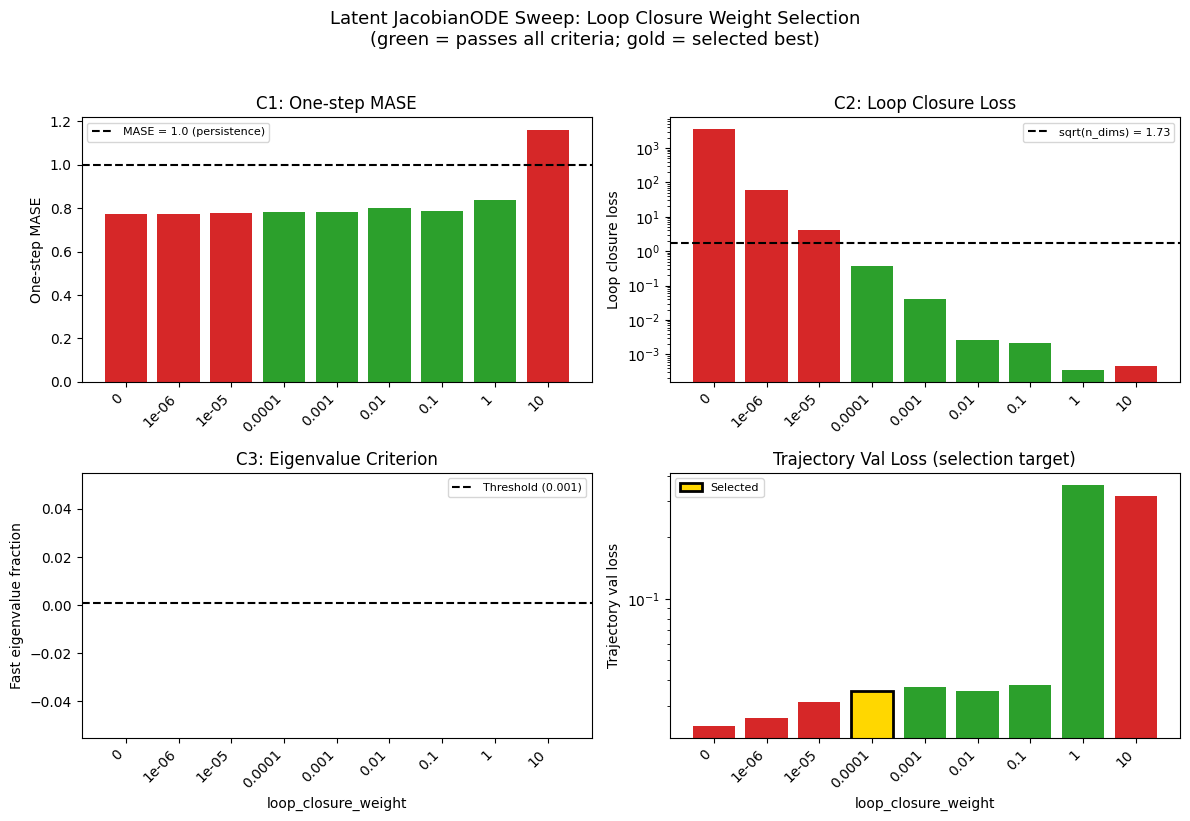

In [77]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

one_step_mases     = [m.one_step_mase             for m in all_diagnostics]
loop_closure_losses = [m.loop_closure_loss         for m in all_diagnostics]
eig_fracs          = [m.fast_eigenvalue_fraction   for m in all_diagnostics]
traj_losses        = [m.trajectory_val_loss        for m in all_diagnostics]

colors  = ['tab:green' if i in result.surviving_indices else 'tab:red'
           for i in range(len(all_diagnostics))]
x_labels = [str(v) for v in sweep_lambdas]
x_pos    = range(len(sweep_lambdas))

# Panel 1: One-step MASE vs persistence threshold (C1)
axes[0, 0].bar(x_pos, one_step_mases, color=colors)
axes[0, 0].axhline(1.0, color='k', ls='--',
                   label='MASE = 1.0 (persistence)')
axes[0, 0].set_ylabel('One-step MASE')
axes[0, 0].set_title('C1: One-step MASE')
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels(x_labels, rotation=45, ha='right')
axes[0, 0].legend(fontsize=8)

# Panel 2: Loop closure loss vs sqrt(n_dims) (C2)
axes[0, 1].bar(x_pos, loop_closure_losses, color=colors)
axes[0, 1].axhline(np.sqrt(n_dims), color='k', ls='--',
                   label=f'sqrt(n_dims) = {np.sqrt(n_dims):.2f}')
axes[0, 1].set_ylabel('Loop closure loss')
axes[0, 1].set_title('C2: Loop Closure Loss')
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(x_labels, rotation=45, ha='right')
axes[0, 1].legend(fontsize=8)
axes[0, 1].set_yscale('log')

# Panel 3: Fast eigenvalue fraction (C3)
axes[1, 0].bar(x_pos, eig_fracs, color=colors)
axes[1, 0].axhline(0.001, color='k', ls='--', label='Threshold (0.001)')
axes[1, 0].set_ylabel('Fast eigenvalue fraction')
axes[1, 0].set_title('C3: Eigenvalue Criterion')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(x_labels, rotation=45, ha='right')
axes[1, 0].set_xlabel('loop_closure_weight')
axes[1, 0].legend(fontsize=8)

# Panel 4: Trajectory val loss (selection target)
axes[1, 1].bar(x_pos, traj_losses, color=colors)
if result.best_index is not None:
    axes[1, 1].bar(result.best_index, traj_losses[result.best_index],
                   color='gold', edgecolor='black', linewidth=2, label='Selected')
axes[1, 1].set_ylabel('Trajectory val loss')
axes[1, 1].set_title('Trajectory Val Loss (selection target)')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(x_labels, rotation=45, ha='right')
axes[1, 1].set_xlabel('loop_closure_weight')
axes[1, 1].legend(fontsize=8)
axes[1, 1].set_yscale('log')

fig.suptitle(
    'Latent JacobianODE Sweep: Loop Closure Weight Selection\n'
    '(green = passes all criteria; gold = selected best)',
    fontsize=13, y=1.02,
)
plt.tight_layout()
plt.show()

### 5e. Load the Best Model for Downstream Use

In [78]:
best_run_id  = sweep_run_ids[result.best_index]
best_lambda  = sweep_lambdas[result.best_index]

print(f"Loading best model: run_id={best_run_id}, lambda={best_lambda}")

Loading best model: run_id=50dlz0gr, lambda=0.0001


In [79]:

# ----------------------------------------------------------------
# Load the trained run from Weights & Biases
# ----------------------------------------------------------------
# Requires Sections 1–2 to have been run (defines TRUE_LYAPUNOV,
# JAC_WINDOW_STRIDE, ENCODER_WARMUP_EPOCHS, SAVE_DIR, etc.)
#
# What this block does:
#   1. Re-generates trajectories from the saved run config
#   2. Normalizes data (z-score, same as Section 3) → gives mu, sigma
#   3. Creates fresh dataloaders from normalized data
#   4. Loads the best checkpoint (lowest mean val loss)
#   5. Restores runtime attributes set manually after model creation

# ---- Step 1: rebuild architecture + raw trajectory data ----
run, cfg, eq, dt, _values_raw, _, _, _, _, lit_model = load_run(
    WANDB_PROJECT_PATH,
    run_id=best_run_id,
    save_dir=SAVE_DIR,
    generate_data=True,
    verbose=True,
)

# ---- Step 2: normalize (must match training-time normalization) ----
values, mu, sigma = normalize_data(_values_raw)
print(f"\nNormalization: mu={mu:.4f}, sigma={sigma:.4f}")

# ---- Step 3: dataloaders from normalized data ----
train_dl, val_dl, test_dl, trajs = create_dataloaders(cfg, values, verbose=True)

# ---- Step 4: load best checkpoint ----
load_checkpoint(run, cfg, lit_model, save_dir=SAVE_DIR, verbose=True)

# ---- Step 5: restore attributes not stored in the wandb config ----
lit_model.true_lyapunov_exponents = torch.tensor(TRUE_LYAPUNOV, dtype=torch.float32)
# jac_window_stride is stored as null in the config (set manually during training)
lit_model.jac_window_stride = JAC_WINDOW_STRIDE          # = 5 for this run
# encoder_warmup_epochs is passed automatically by make_model when stored in cfg.model,
# but set explicitly here as a safeguard
lit_model.encoder_warmup_epochs = ENCODER_WARMUP_EPOCHS  # = 0 for this run

lit_model.eval()
print(f"\nLoaded run: {run.name}  (id={run.id})")
print(f"  dt={dt:.4f},  mu={mu:.4f},  sigma={sigma:.4f}")
print(f"  jac_window_stride={lit_model.jac_window_stride}")
print(f"  encoder_warmup_epochs={lit_model.encoder_warmup_epochs}")
print(f"  true_lyapunov_exponents={lit_model.true_lyapunov_exponents.tolist()}")
print(f"\nModel ready for testing (Sections 6+).")



Normalization: mu=8.4429, sigma=14.2548


Sequence Indices:   0%|          | 0/1450 [00:00<?, ?it/s]

Train dataset shape: torch.Size([31900, 50, 3])
Validation dataset shape: torch.Size([10150, 50, 3])
Test dataset shape: torch.Size([4350, 50, 3])
Train trajectories dataset shape: torch.Size([22, 1500, 3])
Validation trajectories dataset shape: torch.Size([7, 1500, 3])
Test trajectories dataset shape: torch.Size([3, 1500, 3])

Loaded run: MLP__hidden_dim_[512, 512, 512]__num_layers_3__residuals_False__dropout_0.0__activation_silu__batch_size_32__optimizer_AdamW__optimizer_kwargs_{'lr': 0.0001, 'weight_decay': 0.0001}__use_scheduler_True__min_lr_1e-06__k_scale_1__gradient_clip_val_1.0__gradient_clip_algorithm_norm__alpha_teacher_forcing_1__teacher_forcing_annealing_True__gamma_teacher_forcing_0.999__teacher_forcing_update_interval_5__teacher_forcing_steps_1__min_alpha_teacher_forcing_0__alpha_validation_0__obs_noise_scale_0.0000__jac_penalty_0.0__jac_norm_ord_fro__reconstruction_loss_weight_1.0__latent_prediction_loss_weight_0.0__loop_closure_training_True__loop_closure_weight_0.0001__

### 6. Testing

In [80]:
sample_batch = test_dl.dataset.sequence[np.random.choice(np.arange(len(test_dl.dataset.sequence)), size=(128,), replace=False)]
test_trajs = trajs['test_trajs'].sequence

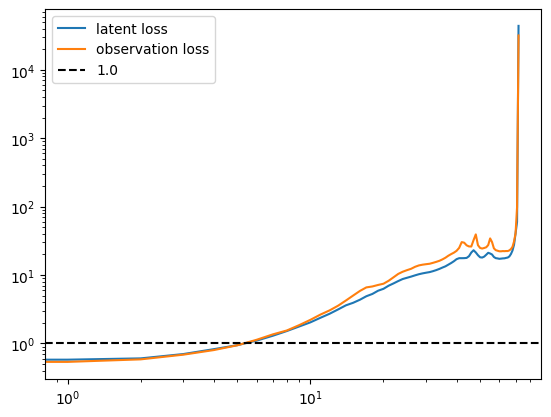

In [81]:
lit_model.prediction_steps = 100
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
lit_model = lit_model.to(device)
with torch.no_grad():
    traj_ret = lit_model.trajectory_model_step(test_trajs.to(device), alpha_teacher_forcing=0.0, return_decoded=True)
    targets = traj_ret['targets']
    decoded = traj_ret['decoded']
    latent_targets = lit_model.encode_trajectory(targets)
    z_pred = traj_ret['outputs']

per_time_step_latent_loss = ((latent_targets - z_pred[:, lit_model.jacobianODEint_kwargs['traj_init_steps']:])**2).mean(axis=(0, 2)).cpu().numpy()
ten_step_latent_loss = per_time_step_latent_loss[:10].mean()
plt.plot(per_time_step_latent_loss/ten_step_latent_loss, label='latent loss')

per_time_step_loss = ((targets.cpu() - decoded.cpu())**2).mean(axis=(0, 2))
ten_step_loss = per_time_step_loss[:10].mean()
plt.plot(per_time_step_loss/ten_step_loss, label='observation loss')

plt.axhline(1.0, color='k', linestyle='--', label='1.0')
plt.legend()
plt.xscale('log')
plt.yscale('log')
plt.show()

In [82]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
lit_model = lit_model.to(device)
lit_model.prediction_steps = 10

# PROCESS SAMPLE BATCH
with torch.no_grad():
    sample_batch = sample_batch.to(device)
    latent_traj = lit_model.encode_trajectory(sample_batch)
    traj_decoded = lit_model.decode_trajectory(latent_traj)

    traj_ret = lit_model.trajectory_model_step(sample_batch, alpha_teacher_forcing=1.0, return_decoded=True)
    targets = traj_ret['targets']
    decoded = traj_ret['decoded']
    latent_targets = lit_model.encode_trajectory(targets)
    z_pred = traj_ret['outputs']

# move everything to cpu
sample_batch = sample_batch.cpu()
latent_traj = latent_traj.cpu()
traj_decoded = traj_decoded.cpu()
latent_targets = latent_targets.cpu()
z_pred = z_pred.cpu()
targets = targets.cpu()
decoded = decoded.cpu()

# PROCESS TEST TRAJS
with torch.no_grad():
    latent_traj_full = lit_model.encode_trajectory(test_trajs.to(device))
    traj_decoded_full = lit_model.decode_trajectory(latent_traj_full)
    jacs_full = lit_model.compute_jacobians(latent_traj_full)
    lyaps_full = lit_model.compute_lyapunov_exponents(jacs_full, dt)

# move everything to cpu
latent_traj_full = latent_traj_full.cpu()
traj_decoded_full = traj_decoded_full.cpu()
jacs_full = jacs_full.cpu()
lyaps_full = lyaps_full.cpu()
lit_model = lit_model.cpu()

In [83]:
true_vars = test_trajs.reshape(-1, 3).var(axis=0)
est_dim_true = (true_vars / true_vars.max()).sum()
latent_vars = latent_traj_full.reshape(-1, 3).var(axis=0)
est_dim_latent = (latent_vars/latent_vars.max()).sum()
print(f"True dim: {est_dim_true:.4f}, Latent dim: {est_dim_latent:.4f}")

True dim: 2.5319, Latent dim: 1.4595


In [84]:
def participation_ratio(X):
    # X should be (N, D) where D is dimension
    X_flat = X.reshape(-1, X.shape[-1])
    cov = np.cov(X_flat, rowvar=False)
    eigvals = np.linalg.eigvalsh(cov)
    pr = (eigvals.sum())**2 / (eigvals**2).sum()
    return pr

pr_true = participation_ratio(test_trajs)
pr_latent = participation_ratio(latent_traj_full)

print(f"Participation Ratio (test_trajs): {pr_true:.4f}")
print(f"Participation Ratio (latent_traj_full): {pr_latent:.4f}")

Participation Ratio (test_trajs): 1.7541
Participation Ratio (latent_traj_full): 1.8496


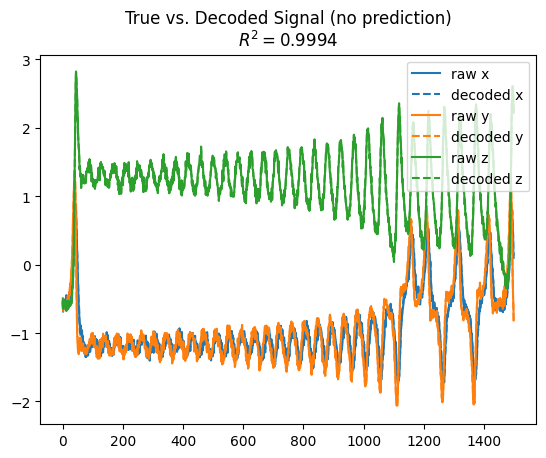

In [85]:
dim_names = ['x', 'y', 'z']
for i in range(3):
    plt.plot(test_trajs[0, :, i].numpy(), c=f"C{i}", label=f'raw {dim_names[i]}')
    plt.plot(traj_decoded_full[0, :, i].numpy(), c=f"C{i}", linestyle='--', label=f'decoded {dim_names[i]}')
plt.title(f"True vs. Decoded Signal (no prediction)\n$R^2 = {r2_score(test_trajs.reshape(-1, 3), traj_decoded_full.reshape(-1, 3)):.4f}$")
plt.legend()
# plt.xlim(0, 100)
plt.show()

In [86]:
W = lit_model.encoder.decoder.net[0].weight.data
cond_number = torch.linalg.cond(W)
singular_values = torch.linalg.svdvals(W)

print(f"Condition number of W: {cond_number.item():.4e}")
print("Singular values of W:", singular_values.cpu().numpy())

Condition number of W: 1.1271e+00
Singular values of W: [3.812033  3.5799434 3.3821898]


In [87]:
lyaps_full.mean(axis=0)

tensor([ -0.9527,  -1.2739, -12.4952])

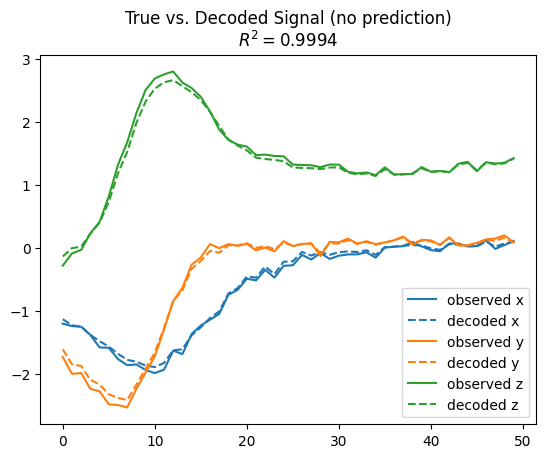

In [88]:
dim_names = ['x', 'y', 'z']
# plot the worst ind
plot_ind = ((sample_batch - traj_decoded)**2).mean(axis=(1, 2)).argmax()
for i in range(3):
    plt.plot(sample_batch[plot_ind, :, i].numpy(), c=f"C{i}", label=f'observed {dim_names[i]}')
    plt.plot(traj_decoded[plot_ind, :, i].numpy(), c=f"C{i}", linestyle='--', label=f'decoded {dim_names[i]}')
plt.title(f"True vs. Decoded Signal (no prediction)\n$R^2 = {r2_score(sample_batch.reshape(-1, 3), traj_decoded.reshape(-1, 3)):.4f}$")
plt.legend()
plt.show()

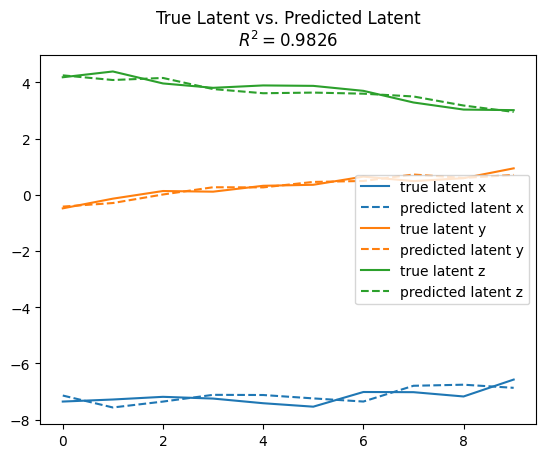

In [89]:
traj_init_steps = lit_model.jacobianODEint_kwargs.get('traj_init_steps', 15)
# plot the worst ind
# plot_ind = ((latent_targets - z_pred[:, traj_init_steps:, :])**2).mean(axis=(1, 2)).argmax()
plot_ind = ((latent_targets - z_pred[:, traj_init_steps:, :])**2).mean(axis=(1, 2)).argmin()
for i in range(3):
    plt.plot(latent_targets[plot_ind, :, i].numpy(), c=f"C{i}", label=f'true latent {dim_names[i]}')
    plt.plot(z_pred[plot_ind, traj_init_steps:, i].numpy(), c=f"C{i}", linestyle='--', label=f'predicted latent {dim_names[i]}')
plt.legend()
r2_val = r2_score(latent_targets.reshape(-1, 3), z_pred[:, traj_init_steps:, :].reshape(-1, 3))
plt.title(f"True Latent vs. Predicted Latent\n$R^2 = {r2_val:.4f}$")
plt.show()

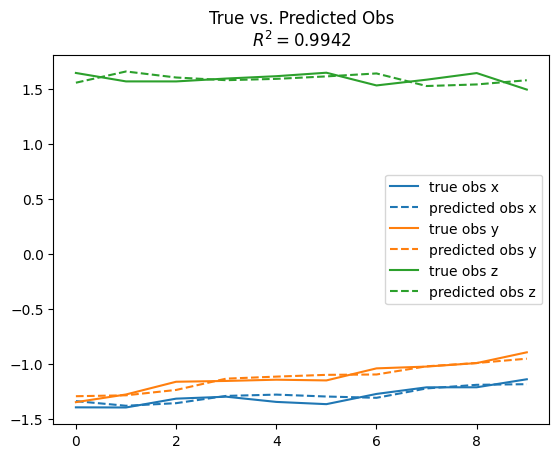

In [90]:
# plot the worst ind
# plot_ind = ((targets - decoded)**2).mean(axis=(1, 2)).argmax()
# plot_ind = ((targets - decoded)**2).mean(axis=(1, 2)).argmin()
for i in range(3):
    plt.plot(targets[plot_ind, :, i].numpy(), c=f"C{i}", label=f'true obs {dim_names[i]}')
    plt.plot(decoded[plot_ind, :, i].numpy(), c=f"C{i}", linestyle='--', label=f'predicted obs {dim_names[i]}')
plt.legend()
r2_val = r2_score(targets.reshape(-1, 3), decoded.reshape(-1, 3))
plt.title(f"True vs. Predicted Obs\n$R^2 = {r2_val:.4f}$")
plt.show()

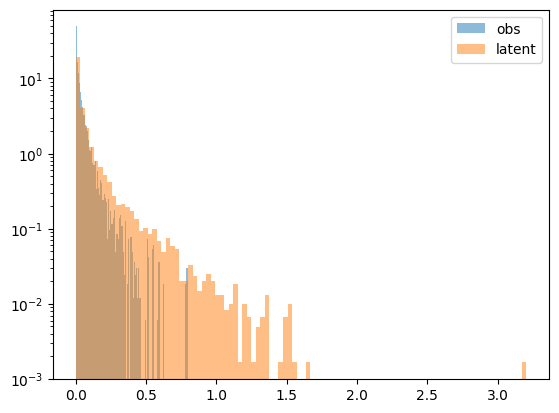

In [91]:
smoothness = (targets[:, 1:] - targets[:, :-1]).pow(2)/targets.var(axis=(0, 1)).unsqueeze(0).unsqueeze(0)
smoothness_latents = (latent_traj[:, 1:] - latent_traj[:, :-1]).pow(2)/latent_traj.var(axis=(0, 1)).unsqueeze(0).unsqueeze(0)
smoothness_pred = (decoded[:, 1:] - decoded[:, :-1]).pow(2)/decoded.var(axis=(0, 1)).unsqueeze(0).unsqueeze(0)

plt.hist(smoothness.flatten(), bins=100, density=True, label='obs', alpha=0.5)
plt.hist(smoothness_latents.flatten(), bins=100, density=True, label='latent', alpha=0.5)
# plt.hist(smoothness_pred.flatten(), bins=100, density=True, label='pred', alpha=0.5)
plt.yscale('log')
plt.legend()

In [92]:
smoothness.mean(), smoothness_latents.mean(), smoothness_pred.mean()

(tensor(0.0355), tensor(0.0711), tensor(0.0241))

## Composite Jacobian: $J_D \, J_{\mathrm{ODE}} \, J_E \approx J_{\mathrm{true}}$

We verify that the autodifferentiated composition of encoder, predicted latent
Jacobian, and decoder recovers the true Lorenz Jacobian.

**Three Jacobians**:
| Symbol | Shape | Computed via |
|--------|-------|--------------|
| $J_E = \partial z_t / \partial x_t$ | (3, 3) | `autograd` through SSM encoder |
| $J_{\mathrm{ODE}}$ | (3, 3) | Jacobian MLP output at $z_t$ |
| $J_D = \partial \hat{x}_t / \partial z_t$ | (3, 3) | `autograd` through pointwise decoder |

**Lorenz Jacobian** at $x = (x_1, x_2, x_3)$ (in normalized coords = same as raw since normalization is a global scalar):
$$
J_{\mathrm{true}}(x) = \begin{pmatrix}
-\sigma & \sigma & 0 \\
\rho - x_3 & -1 & -x_1 \\
x_2 & x_1 & -\beta
\end{pmatrix}
$$

**Expected result**: $J_D J_{\mathrm{ODE}} J_E \approx J_{\mathrm{true}}$ entry-by-entry.

In [93]:
# ---------------------------------------------------------------
# Helper: analytical Lorenz Jacobian
# Note: Since normalization is x_norm = (x - mu)/sigma (global scalar),
# J_lorenz(x_norm) == J_lorenz(x_raw).  Pass denormalized x.
# ---------------------------------------------------------------
def lorenz_jacobian(x_raw, sigma_lz=10.0, rho=28.0, beta=8.0/3.0):
    """Analytical Lorenz Jacobian at x_raw = (x1, x2, x3)."""
    x1, x2, x3 = float(x_raw[0]), float(x_raw[1]), float(x_raw[2])
    return torch.tensor([
        [-sigma_lz, sigma_lz,    0.0 ],
        [rho - x3,  -1.0,       -x1  ],
        [x2,         x1,        -beta],
    ], dtype=torch.float32)


# ---------------------------------------------------------------
# Helper: encoder Jacobian  J_E = d(z_t)/d(x_t)
# We replace x_t in the full sequence and differentiate.
# For the SSM this gives the *partial* Jacobian w.r.t. x_t
# (history x_{0:t-1} is treated as fixed constants).
# ---------------------------------------------------------------
def compute_J_E(lit_model, x_seq, t_idx):
    """
    Args:
        x_seq : (1, T, D_obs) — single sequence (batch dim = 1)
        t_idx : int           — timestep to differentiate at
    Returns:
        J_E : (D_latent, D_obs) tensor
    """
    x_detached = x_seq.detach()

    def f(x_t):
        # x_t: (D_obs,) — the input we differentiate w.r.t.
        x_new = torch.cat([
            x_detached[:, :t_idx, :],
            x_t.view(1, 1, -1),
            x_detached[:, t_idx+1:, :],
        ], dim=1)  # (1, T, D_obs)
        z = lit_model.encoder.encode(x_new)  # (1, T, D_latent)
        return z[0, t_idx]                   # (D_latent,)

    return autograd_jacobian(f, x_detached[0, t_idx])  # (D_latent, D_obs)


# ---------------------------------------------------------------
# Helper: decoder Jacobian  J_D = d(decode(z_t))/d(z_t)
# ---------------------------------------------------------------
def compute_J_D(lit_model, z_t):
    """
    Args:
        z_t : (D_latent,) tensor
    Returns:
        J_D : (D_obs, D_latent) tensor
    """
    def f(z):
        # z: (D_latent,) → (D_obs,)
        return lit_model.encoder.decode(z.unsqueeze(0)).squeeze(0)

    return autograd_jacobian(f, z_t)  # (D_obs, D_latent)


# ---------------------------------------------------------------
# Helper: predicted latent Jacobian  J_ODE = Jac MLP at z_t
# ---------------------------------------------------------------
def compute_J_ODE(lit_model, z_t):
    """
    Args:
        z_t : (D_latent,) tensor
    Returns:
        J_ODE : (D_latent, D_latent) tensor
    """
    return lit_model.compute_jacobians(
        z_t.unsqueeze(0).unsqueeze(0)  # (1, 1, D_latent)
    )[0, 0]                            # (D_latent, D_latent)


print("Helper functions defined.")

Helper functions defined.


In [94]:
# ---------------------------------------------------------------
# Compute composite Jacobians on a test trajectory (GPU if available)
# ---------------------------------------------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
lit_model = lit_model.to(device)
lit_model.eval()

# Use one long test sequence; skip the first few timesteps so the
# SSM has accumulated some causal context.
test_seq = trajs['test_trajs'].sequence[:1].to(device)
T_test   = test_seq.shape[1]

# --- sigma and mu may be float or tensor; ensure they're tensors on device
def to_device(x, device):
    if torch.is_tensor(x):
        return x.to(device)
    return torch.tensor(x, dtype=torch.float32, device=device)

sigma_device = to_device(sigma, device)
mu_device    = to_device(mu, device)

# Evaluate every STEP-th timestep to keep runtime reasonable.
STEP       = 2
T_START    = 5   # skip early steps (minimal SSM context)
t_indices  = range(T_START, T_test - 1, STEP)

J_composites = []
J_trues      = []

with torch.no_grad():
    z_seq = lit_model.encode_trajectory(test_seq)  # (1, T', 3)

for t_idx in tqdm(t_indices):
    z_t   = z_seq[0, t_idx].detach()
    x_t_n = test_seq[0, t_idx].detach()

    # --- J_ODE: predicted continuous latent Jacobian ---
    with torch.no_grad():
        J_ode = compute_J_ODE(lit_model, z_t)  # (3, 3)

    # --- J_D: decoder Jacobian (autograd) ---
    with torch.enable_grad():
        J_d = compute_J_D(lit_model, z_t)      # (3, 3)

    # --- J_E: encoder Jacobian (autograd, partial w.r.t. x_t) ---
    with torch.enable_grad():
        # Note: test_seq must be kept on device for compute_J_E
        J_e = compute_J_E(lit_model, test_seq, t_idx)  # (3, 3)

    # --- Composite ---
    J_comp = J_d @ J_ode @ J_e               # (3, 3)

    # --- True Lorenz Jacobian (in raw/denormalized coords = same as norm) ---
    x_raw = x_t_n * sigma_device + mu_device               # denormalize
    J_true = lorenz_jacobian(x_raw)  # Should work on torch tensors

    # Store results on CPU for further processing/analysis
    J_composites.append(J_comp.detach().cpu())
    # lorenz_jacobian might return tensor or numpy; ensure torch tensor on CPU
    if torch.is_tensor(J_true):
        J_trues.append(J_true.detach().cpu())
    else:
        J_trues.append(torch.as_tensor(J_true, dtype=torch.float32).cpu())

J_composites = torch.stack(J_composites)    # (N_t, 3, 3)
J_trues      = torch.stack(J_trues)         # (N_t, 3, 3)

print(f"Evaluated {len(t_indices)} timesteps.")
print(f"J_composites shape: {J_composites.shape}")

  0%|          | 0/747 [00:00<?, ?it/s]

Evaluated 747 timesteps.
J_composites shape: torch.Size([747, 3, 3])


In [95]:
# ---------------------------------------------------------------
# Summary metrics
# ---------------------------------------------------------------
frob_errors = torch.norm(J_composites - J_trues, dim=(-2, -1))   # (N_t,)
frob_true   = torch.norm(J_trues,                dim=(-2, -1))
rel_errors  = frob_errors / (frob_true + 1e-8)

# Pearson correlation across all (i,j) entries and timesteps
comp_flat = J_composites.reshape(-1).numpy()
true_flat = J_trues.reshape(-1).numpy()
corr = float(np.corrcoef(comp_flat, true_flat)[0, 1])
r2_val = r2_score(true_flat, comp_flat)

print("Composite Jacobian test results")
print("=" * 38)
print(f"Frobenius error  — mean: {frob_errors.mean():.4f}  |  std: {frob_errors.std():.4f}")
print(f"Relative error   — mean: {rel_errors.mean():.4f}  |  std: {rel_errors.std():.4f}")
print(f"Entry correlation:       {corr:.4f}")
print(f"R^2:                     {r2_val:.4f}")

# Per-entry breakdown
print("\nPer-entry mean absolute error:")
mae_matrix = (J_composites - J_trues).abs().mean(dim=0).numpy()
print(np.round(mae_matrix, 4))

print("\nMean composite Jacobian:")
print(np.round(J_composites.mean(dim=0).numpy(), 3))

print("\nMean true Lorenz Jacobian:")
print(np.round(J_trues.mean(dim=0).numpy(), 3))

Composite Jacobian test results
Frobenius error  — mean: 13.1895  |  std: 6.2640
Relative error   — mean: 0.5997  |  std: 0.2082
Entry correlation:       0.7583
R^2:                     0.5649

Per-entry mean absolute error:
[[3.6753 3.4637 1.4987]
 [8.7488 3.2808 3.5553]
 [2.2792 2.503  1.5438]]

Mean composite Jacobian:
[[-6.427  6.546  1.113]
 [-5.38   2.24   3.141]
 [-6.41  -3.223 -3.614]]

Mean true Lorenz Jacobian:
[[-10.     10.      0.   ]
 [  3.227  -1.      4.958]
 [ -4.903  -4.958  -2.667]]
